In [1]:
import whisper
import sounddevice as sd
import soundfile as sf
import tempfile
import threading
import time
import pyttsx3
import cv2
import os
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
import numpy as np
import time
from sklearn.metrics.pairwise import cosine_similarity
import threading
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import mediapipe as mp
import time
import pygame

ModuleNotFoundError: No module named 'whisper'

In [2]:
# -------- Configuration --------
MODEL_NAME = "medium.en"
RECORD_SECONDS = 4
SAMPLE_RATE = 16000
WAKE_PHRASES = ["guard my room", "guard my room please", "guard", "activate guard", "start guard"]
DISARM_PHRASES = ["stop guard", "disarm", "deactivate guard", "stop guard please", "stop"]

In [3]:
# Set default audio input device (change index if needed)
try:
    sd.default.device = sd.query_devices(kind='input')['name']
except Exception as e:
    print("[audio] Could not set default device:", e)

# persistent webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("[webcam] ERROR: cannot open webcam")

# ...existing code...
def record_chunk(seconds=RECORD_SECONDS, samplerate=SAMPLE_RATE, pre_silence: float = 0.0):
    """
    Record `seconds` of audio. If pre_silence > 0, record (pre_silence + seconds)
    then discard the initial pre_silence portion — useful to avoid capturing
    recent TTS playback.
    """
    total = seconds + (pre_silence or 0.0)
    print(f"[audio] recording {seconds}s (with {pre_silence}s pre-silence)...")
    try:
        recording = sd.rec(int(total * samplerate), samplerate=samplerate, channels=1, dtype='float32')
        sd.wait()
    except Exception as e:
        print("[audio] ERROR:", e)
        return None

    # trim leading pre_silence
    if pre_silence and pre_silence > 0.0:
        start = int(pre_silence * samplerate)
        trimmed = recording[start:]
    else:
        trimmed = recording

    tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
    sf.write(tmp.name, trimmed, samplerate)
    return tmp.name
# ...existing code...

def contains_phrase(text, phrases):
    text = text.lower()
    return any(p in text for p in phrases)

def get_webcam_frame():
    ret, frame = cap.read()
    if not ret:
        return None
    return frame

out_widget = widgets.Output()
display(out_widget)
cap.release()


Output()

In [4]:
# def main():
#     global cap
#     cap = cv2.VideoCapture(0)
#     if not cap.isOpened():
#         print("[webcam] ERROR: cannot open webcam")
#         return

#     agent = GuardAgent()
#     print("Say a wake phrase (e.g., 'Guard my room') to activate. Say a disarm phrase to stop.")

#     try:
#         while True:
#             agent.listen_and_toggle()

#             if not agent.guard_mode:
#                 frame = get_webcam_frame()
#                 if frame is not None:
#                     _, encoded_img = cv2.imencode('.png', frame)
#                     img_bytes = encoded_img.tobytes()
#                     with out_widget:
#                         clear_output(wait=True)
#                         display(widgets.Image(value=img_bytes, format='png', width=640, height=480))
#             time.sleep(0.1)

#     except KeyboardInterrupt:
#         print("\n[exit] KeyboardInterrupt received — cleaning up.")
#     finally:
#         cap.release()
#         print("[exit] done.")

# main()

In [5]:
import mediapipe as mp
import cv2
import numpy as np
import os
from sklearn.metrics.pairwise import cosine_similarity

mp_face_mesh = mp.solutions.face_mesh

BASE_DIR = "enrolled_faces"
os.makedirs(BASE_DIR, exist_ok=True)


def extract_embedding(image_path):
    """Extract a 3D face landmark embedding from an image."""
    img = cv2.imread(image_path)
    if img is None:
        print("[enroll] Could not read image:", image_path)
        return None

    with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True) as face_mesh:
        results = face_mesh.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if not results.multi_face_landmarks:
            print("[enroll] No face found in", image_path)
            return None
        landmarks = results.multi_face_landmarks[0].landmark
        emb = np.array([[lm.x, lm.y, lm.z] for lm in landmarks]).flatten()
        emb = emb / np.linalg.norm(emb)
        return emb

def enroll_face(person_name, image_paths):
    person_dir = os.path.join(BASE_DIR, person_name)
    os.makedirs(person_dir, exist_ok=True)

    for i, path in enumerate(image_paths):  # keep enumerate
        if not os.path.exists(path):
            print("[enroll] File not found:", path)
            continue
        emb = extract_embedding(path)
        if emb is not None:
            np.save(os.path.join(person_dir, f"{i}.npy"), emb)
            print(f"[enroll] Saved embedding {i+1} for {person_name}")
    print(f"[enroll] Completed enrollment for {person_name} ✅")



In [6]:
# enroll_face("Vishal", ["enrolled_faces/vishal1.jpg", "enrolled_faces/vishal2.jpg"])

In [7]:
def recognize_face_with_score(frame, threshold=0.9):
    """
    Recognize face from frame by comparing with all enrolled faces.
    Uses majority vote: counts embeddings exceeding threshold per person.
    Returns the person with the maximum count.
    """
    with mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True) as face_mesh:
        results = face_mesh.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if not results.multi_face_landmarks:
            return "Unknown", frame, 0.0

        landmarks = results.multi_face_landmarks[0].landmark
        emb = np.array([[lm.x, lm.y, lm.z] for lm in landmarks]).flatten()
        emb = emb / np.linalg.norm(emb)

        best_name, best_count, best_sim = "Unknown", 0, 0.0

        for person_name in os.listdir(BASE_DIR):
            person_dir = os.path.join(BASE_DIR, person_name)
            if not os.path.isdir(person_dir):
                continue

            count_above_thresh = 0
            sims = []

            for f in os.listdir(person_dir):
                if not f.endswith(".npy"):
                    continue
                known_emb = np.load(os.path.join(person_dir, f))
                sim = cosine_similarity([emb], [known_emb])[0][0]
                sims.append(sim)
                if sim >= threshold:
                    count_above_thresh += 1

            # Majority vote
            if count_above_thresh > best_count:
                best_count = count_above_thresh
                best_name = person_name
                if sims:
                    best_sim = max(sims)

        # No one exceeded threshold
        if best_count == 0:
            best_name = "Unknown"
            best_sim = 0.0

        return best_name, frame, best_sim


In [16]:
# ...existing code...
import requests
from typing import Optional


try:
    from langchain_community.chat_models import ChatOllama
except Exception:
    ChatOllama = None  # type: ignore

from langchain.schema import HumanMessage, SystemMessage, AIMessage  # << added AIMessage

_DEF_SYSTEM = "You are a polite, safety-focused guard assistant. Be brief and respectful."

conv_widget = widgets.Textarea(
    value="",
    placeholder="Conversation will appear here...",
    layout=widgets.Layout(width="100%", height="240px"),
    disabled=True,
)
display(conv_widget)

def _append_conversation(role: str, text: str):
    ts = time.strftime("%H:%M:%S")
    # keep a limited history shown (optional)
    max_chars = 20000
    entry = f"[{ts}] {role}: {text}\n\n"
    conv_widget.value = (conv_widget.value + entry)[-max_chars:]
      

def _probe_ollama(host: str = "http://localhost:11434", timeout: float = 0.75) -> bool:
    try:
        requests.get(f"{host}/api/tags", timeout=timeout)
        return True
    except Exception:
        return False


def _get_llm() -> Optional["ChatOllama"]:
    if ChatOllama is None:
        return None
    if not _probe_ollama():
        print("[dialogue] Ollama server not available at localhost:11434 — using offline fallback replies.")
        return None
    try:
        return ChatOllama(model="llama3")  # or another local model you've pulled
    except Exception:
        print("[dialogue] Could not initialize ChatOllama — using offline fallback replies.")
        return None


_LLM = _get_llm()

# conversation history (starts with system prompt)
_CONV_HISTORY = [SystemMessage(content=_DEF_SYSTEM)]  # << new global conversation history


def _fallback_reply(prompt: str) -> str:
    p = prompt.lower()
    if "who are you" in p or "identify" in p:
        return "I am a home security assistant. Please identify yourself."
    if "ask them to leave" in p or "please leave" in p:
        return "Please step away from the door. This area is restricted."
    if "stern" in p or "alarm" in p or "intruder" in p:
        return "Warning. Security protocol active. Leave the area immediately."
    return "Please state your purpose. This area is monitored."


# ...existing code...
def generate_dialogue(prompt: str, reset_history: bool = False) -> str:
    """
    Append the user's prompt to conversation history, call the LLM (or fallback),
    append assistant reply to history and return it. Also update the on-screen
    conversation widget so you can watch the full dialog live.
    """
    global _CONV_HISTORY
    if reset_history:
        _CONV_HISTORY = [SystemMessage(content=_DEF_SYSTEM)]
        try:
            conv_widget.value = ""
        except Exception:
            pass

    # append human message to internal history and UI
    _CONV_HISTORY.append(HumanMessage(content=prompt))
    try:
        _append_conversation("User", prompt)
    except Exception:
        pass

    if _LLM is None:
        reply = _fallback_reply(prompt)
    else:
        try:
            # pass full conversation history
            response = _LLM.invoke(_CONV_HISTORY)
            reply = getattr(response, "content", "") or _fallback_reply(prompt)
        except Exception:
            reply = _fallback_reply(prompt)

    # Append assistant reply to history and UI
    _CONV_HISTORY.append(AIMessage(content=reply))
    try:
        _append_conversation("Assistant", reply)
    except Exception:
        pass

    return reply
# ...existing code...

Textarea(value='', disabled=True, layout=Layout(height='240px', width='100%'), placeholder='Conversation will …

[dialogue] Ollama server not available at localhost:11434 — using offline fallback replies.


In [19]:
# ...existing code...
class GuardAgent:
    def __init__(self, cap):
        print("[init] loading Whisper model:", MODEL_NAME)
        self.model = whisper.load_model(MODEL_NAME)
        # Force macOS NSSS driver for pyttsx3 (more reliable on mac)
        try:
            self.tts = pyttsx3.init('nsss')
        except Exception:
            self.tts = pyttsx3.init()
        self.tts.setProperty("rate", 150)

        self.guard_mode = False
        self.cap = cap
        self.last_name = None
        self.last_detect_time = 0
        self.guard_thread = None
        self.guard_stop_event = threading.Event()
        self.intruder_levels = {}   # name -> level (0..3)
        self.level_timers = {}      # name -> last escalation time

        # Do not init pygame mixer immediately to avoid audio device conflicts with TTS.
        self._mixer_inited = False
        self.alarm_file = "alarm1.mp3"
        self.alarm_playing = False

    # ensure pygame mixer initialized only when needed
    def _ensure_mixer(self):
        if not self._mixer_inited:
            try:
                pygame.mixer.init()
                self._mixer_inited = True
            except Exception as e:
                print("[audio] pygame.mixer.init() failed:", e)
                self._mixer_inited = False

    # Stop mixer to allow pyttsx3 to use device, then re-init if alarm needed
    def _pause_mixer_for_tts(self):
        try:
            if self._mixer_inited:
                pygame.mixer.quit()
                self._mixer_inited = False
        except Exception:
            pass

    def _resume_mixer_if_needed(self):
        # Re-init mixer only if we need alarm playback later
        if os.path.exists(self.alarm_file):
            self._ensure_mixer()

    def speak(self, text: str):
        """Speak text using pyttsx3 while avoiding mixer conflicts."""
        if not text:
            return
        # stop pygame audio temporarily so TTS can access the device
        self._pause_mixer_for_tts()
        try:
            self.tts.say(text)
            self.tts.runAndWait()
        except Exception as e:
            print("[tts] error:", e)
            # fallback to macOS 'say' if pyttsx3 fails
            try:
                os.system(f'say "{text}"')
            except Exception:
                pass
        # short pause to let audio device settle
        time.sleep(0.25)
        # resume mixer if alarm will be used later
        self._resume_mixer_if_needed()

    def play_alarm(self):
        self._ensure_mixer()
        if os.path.exists(self.alarm_file) and not self.alarm_playing:
            try:
                pygame.mixer.music.load(self.alarm_file)
                pygame.mixer.music.play(-1)
                self.alarm_playing = True
            except Exception as e:
                print("[alarm] could not play alarm:", e)
                self.alarm_playing = False

    def stop_alarm(self):
        if self._mixer_inited and self.alarm_playing:
            try:
                pygame.mixer.music.stop()
            except Exception:
                pass
        self.alarm_playing = False

    # ...existing code...
    def converse_round(self, prompt: str, listen_seconds: int = 4) -> str:
        """
        Send prompt to LLM (append context), play reply, then listen for user's follow-up.
        Uses a short post-TTS pause and trims first 0.5s of the recording to avoid
        capturing TTS playback.
        """
        # Get assistant reply (history-aware)
        reply = generate_dialogue(prompt)
        print("[assistant]", reply)

        # Speak reply (blocking)
        self.speak(reply)

        # longer pause to let playback settle / avoid being recorded
        time.sleep(0.6)

        # Record user's response and transcribe — discard first 0.5s of recording
        wav_path = record_chunk(seconds=listen_seconds, pre_silence=0.5)
        if not wav_path:
            return ""
        try:
            result = self.model.transcribe(wav_path, language="en")
            user_text = result.get("text", "").strip()
        except Exception as e:
            print("[transcribe] error after assistant:", e)
            user_text = ""
        finally:
            try:
                os.remove(wav_path)
            except Exception:
                pass

        print("[user reply heard]", user_text)
        if user_text:
            # add user reply to conversation context so next generate_dialogue continues the convo
            _ = generate_dialogue(user_text)
        return user_text

    def listen_for_followup(self, listen_seconds: int = 3) -> str:
        """
        Record short audio after assistant speaks and return transcribed text.
        Returns empty string on failure / silence.
        """
        wav_path = record_chunk(seconds=listen_seconds, pre_silence=0.0)
        if not wav_path:
            return ""
        try:
            result = self.model.transcribe(wav_path, language="en")
            user_text = result.get("text", "").strip()
        except Exception as e:
            print("[transcribe] error in listen_for_followup:", e)
            user_text = ""
        finally:
            try:
                os.remove(wav_path)
            except Exception:
                pass
        print("[user reply heard]", user_text)
        return user_text   

    def run_guard_mode(self):
        print("[guard] Running face detection...")
        mp_face = mp.solutions.face_detection
        plt.ion()
        fig, ax = plt.subplots()

        with mp_face.FaceDetection(model_selection=0, min_detection_confidence=0.5) as detector:
            while self.guard_mode and not self.guard_stop_event.is_set():
                ret, frame = self.cap.read()
                if not ret:
                    break

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = detector.process(rgb)

                intruder_present = False  # Track if any unknown intruder is present in this frame

                if results.detections:
                    for det in results.detections:
                        bboxC = det.location_data.relative_bounding_box
                        ih, iw, _ = frame.shape
                        x1 = int(bboxC.xmin * iw)
                        y1 = int(bboxC.ymin * ih)
                        w = int(bboxC.width * iw)
                        h = int(bboxC.height * ih)
                        x2 = x1 + w
                        y2 = y1 + h

                        # Draw rectangle
                        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

                        # Crop face for recognition
                        face_crop = frame[max(0, y1):min(ih, y2), max(0, x1):min(iw, x2)]
                        name = "Unknown"
                        sim = 0.0

                        if face_crop.size > 0:
                            name, _, sim = recognize_face_with_score(face_crop)

                        # Prepare description for the LLM
                        desc = f"Detected person: {name}. similarity={sim:.2f}. bbox=({x1},{y1},{w},{h})."
                        # If unknown, escalate level and notify LLM periodically
                        last_time = self.level_timers.get(name, 0)
                        level = self.intruder_levels.get(name, 0)

                        now = time.time()
                        # mark intruder presence
                        if name == "Unknown":
                            intruder_present = True
                            # escalate every 10s
                            if now - last_time > 10:
                                # increase level up to 3
                                new_level = min(level + 1, 3)
                                self.intruder_levels[name] = new_level
                                self.level_timers[name] = now
                                # send a concise text summary to LLM
                                llm_msg = f"ALERT: unknown person detected. LEVEL {new_level}. bbox={x1},{y1},{w},{h}."
                                assistant_reply = generate_dialogue(llm_msg)
                                print("[assistant]", assistant_reply)
                                # speak the assistant reply (handles mixer conflicts)
                                self.speak(assistant_reply)

                                # if serious, start alarm after speaking
                                if new_level >= 3:
                                    # small pause to allow LLM reply to finish
                                    time.sleep(0.4)
                                    self.play_alarm()
                        else:
                            # Known person -> welcome once when first seen
                            if name != self.last_name:
                                welcome_msg = f"Hello {name}. Identity confirmed."
                                assistant_reply = generate_dialogue(welcome_msg)
                                print("[assistant]", assistant_reply)
                                self.speak(assistant_reply)
                            # reset timers/levels for known person
                            self.intruder_levels[name] = 0
                            self.level_timers[name] = now

                        self.last_name = name
                        self.last_detect_time = now

                        # Draw name
                        cv2.putText(frame, f"{name}", (x1, y2 + 30),
                                    cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                                    (0, 255, 0) if name != "Unknown" else (0, 0, 255), 2)

                # STOP alarm if no intruder detected in this frame
                if not intruder_present and self.alarm_playing:
                    self.stop_alarm()

                # Display frame
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                ax.clear()
                ax.imshow(frame_rgb)
                ax.axis('off')
                clear_output(wait=True)
                display(fig)
                plt.pause(0.01)

        plt.close(fig)
# ...existing code...


[exit] KeyboardInterrupt received — cleaning up.


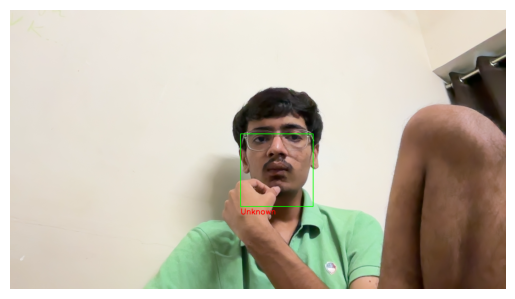

[exit] done.


In [20]:
# def main():
#     cap = cv2.VideoCapture(0)
#     if not cap.isOpened():
#         print("[webcam] cannot open webcam")
#         return
#     agent = GuardAgent(cap)
#     print("Say 'guard my room' to activate. Say 'stop guard' to stop.")

#     try:
#         while True:
#             agent.listen_and_toggle()
#             # Optional: show webcam preview when not in guard mode
#             if not agent.guard_mode:
#                 frame = get_webcam_frame()
#                 if frame is not None:
#                     _, encoded_img = cv2.imencode('.png', frame)
#                     img_bytes = encoded_img.tobytes()
#                     with out_widget:
#                         clear_output(wait=True)
#                         display(widgets.Image(value=img_bytes, format='png', width=640, height=480))
#             time.sleep(0.1)
#     except KeyboardInterrupt:
#         print("\n[exit] KeyboardInterrupt received — cleaning up.")
#     finally:
#         if hasattr(agent, 'alarm_playing') and agent.alarm_playing:
#             pygame.mixer.music.stop()
#             agent.alarm_playing = False
#         cap.release()
#         print("[exit] done.")

# main()

def main():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("[webcam] cannot open webcam")
        return

    agent = GuardAgent(cap)

    # Force guard mode ON immediately
    agent.guard_mode = True
    agent.guard_stop_event.clear()
    agent.guard_thread = threading.Thread(target=agent.run_guard_mode, daemon=True)
    agent.guard_thread.start()

    print("[init] Guard mode activated automatically.")
    print("Say 'stop guard' to stop.")

    try:

        while True:
            # Skip listen_and_toggle() since guard is always ON
            # agent.listen_and_toggle()

            # Optional: show webcam preview when not in guard mode
            if not agent.guard_mode:
                frame = get_webcam_frame()
                if frame is not None:
                    _, encoded_img = cv2.imencode('.png', frame)
                    img_bytes = encoded_img.tobytes()
                    with out_widget:
                        clear_output(wait=True)
                        display(widgets.Image(value=img_bytes, format='png', width=640, height=480))

            time.sleep(0.1)
    except KeyboardInterrupt:
        print("\n[exit] KeyboardInterrupt received — cleaning up.")
    finally:
        if hasattr(agent, 'alarm_playing') and agent.alarm_playing:
            pygame.mixer.music.stop()
            agent.alarm_playing = False
        cap.release()
        print("[exit] done.")

main()

